# Observations

In [ ]:
acc_obs = []
rmse_obs = []
factor = 30
for t in range(1460):
    if t % 50 == 0:
        print(t)
    upscaled_obs = np.load('/pscratch/sd/m/maadrian/output/ERA5/2023/vary_obs/new_framework_GLOBAL_FCNinterpyHnotIdyLdx_q0.5r0.05n1woodbury_qfactor{}GLOBALsmooth4_030324/obs_upscaled{}.npy'.format(factor,t))
    truth = h5py.File("/pscratch/sd/m/maadrian/data/ERA5_2023/2023/2023.h5")['fields'][t+1,:,:,:]
    m = np.load("/pscratch/sd/m/maadrian/stats_v0/ERA5/global_means.npy")[0,:20,:,:]
    s = np.load("/pscratch/sd/m/maadrian/stats_v0/ERA5/global_stds.npy")[0,:20,:,:]
    truth = (truth-m)/s
    
    upscaled_obs = torch.from_numpy(upscaled_obs).unsqueeze(0)
    truth = torch.from_numpy(truth).unsqueeze(0)

    acc_obs.append(weighted_acc_channels(upscaled_obs, truth))
    rmse_obs.append(weighted_rmse_channels(upscaled_obs, truth))

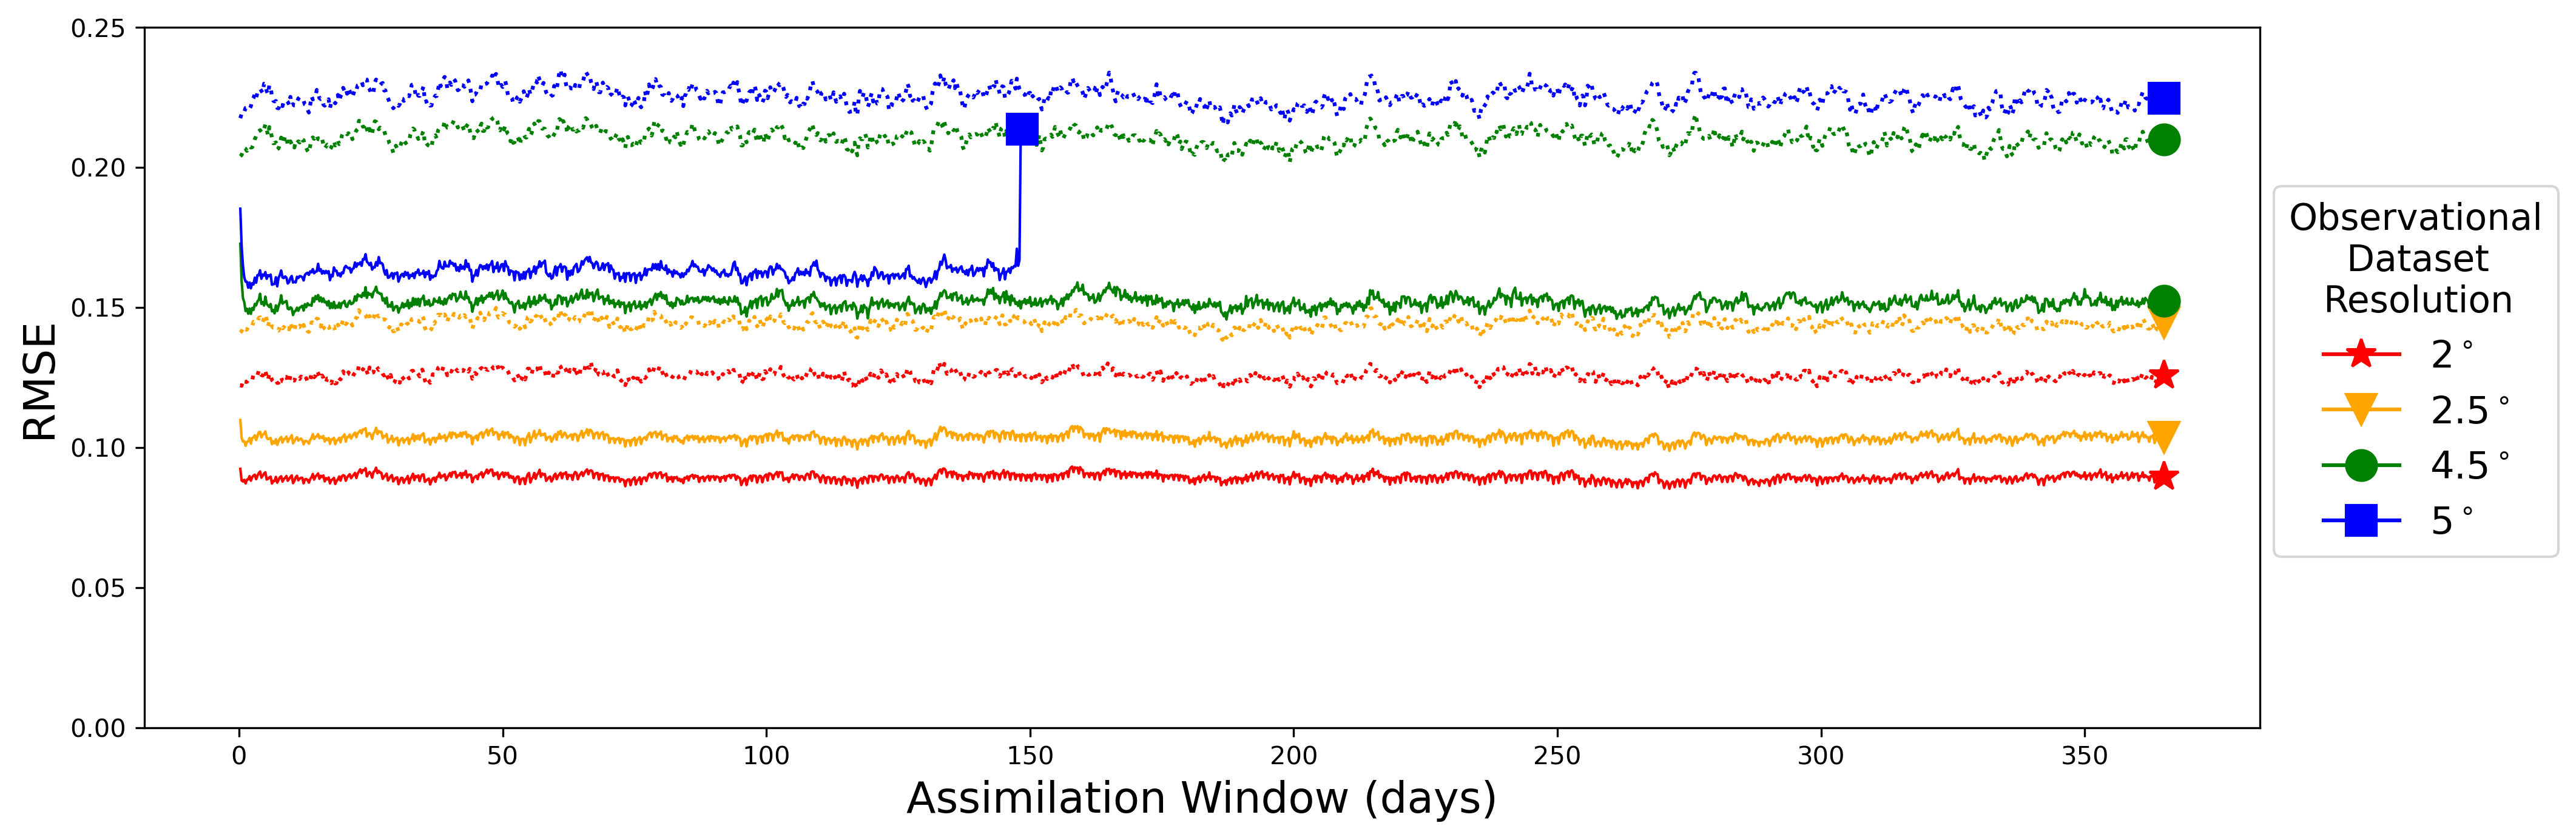

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
figure(figsize=(15*1, 5*1), dpi=300)


rmse_mean_list = []
rmse_std_list = []
rmse_tpt_list = []
path = "/pscratch/sd/m/maadrian/output/ERA5/2023/vary_obs"

obs_size =8
shapes = ["*", "v", "o", "s"]
rmse = np.load("/pscratch/sd/m/maadrian/output/ERA5/2023/vary_obs/new_framework_GLOBAL_FCNinterpyHnotIdyLdx_q0.5r0.0001n1woodbury_qfactor{}GLOBALsmooth4_041124/enkf_filtering_rmse_factor{}.npy".format(obs_size,obs_size))
rmse_se = np.load("/pscratch/sd/m/maadrian/output/ERA5/2023/vary_obs/new_framework_GLOBAL_FCNinterpyHnotIdyLdx_q0.5r0.0001n1woodbury_qfactor{}GLOBALsmooth4_041124/enkf_se_filtering_rmse_factor{}.npy".format(obs_size,obs_size))

rmse_mean_list.append(rmse.mean())
rmse_std_list.append(np.std(rmse))
rmse_tpt_list.append(len(rmse))

t = len(rmse)
plt.plot(np.arange(6/24,(t+1)*6/24,6/24), np.array(rmse), c = 'r', linewidth = 1)
plt.plot((t+1)*6/24, np.array(rmse)[-1], c = 'r', label = "2$^\circ$", marker = shapes[0], markersize = 12)
upscaled_obs =  np.load("/pscratch/sd/m/maadrian/output/ERA5/2023/vary_obs/new_framework_GLOBAL_FCNinterpyHnotIdyLdx_q0.5r0.0001n1woodbury_qfactor8GLOBALsmooth4_041124/rmse_upscaled_obs.npy").mean(axis = (1,2))
plt.plot(np.arange(6/24,(len(upscaled_obs)+1)*6/24,6/24), upscaled_obs, c = 'r', linestyle = 'dotted')
plt.plot((len(upscaled_obs)+1)*6/24, upscaled_obs[-1], c = 'r', marker = shapes[0], markersize=12 )


obs_list = [10,18,20]
degrees = ["2.5$^\circ$", "4.5$^\circ$", "5$^\circ$"]
c_list = ['orange', 'green',  'blue']

for n in range(len(obs_list)):
    rmse = np.load(path + "/new_framework_GLOBAL_FCNinterpyHnotIdyLdx_q0.5r0.0001n1woodbury_qfactor{}GLOBALsmooth4_041124/enkf_filtering_rmse_factor{}.npy".format(obs_list[n],obs_list[n]))
    rmse_se = np.load(path + "/new_framework_GLOBAL_FCNinterpyHnotIdyLdx_q0.5r0.0001n1woodbury_qfactor{}GLOBALsmooth4_041124/enkf_se_filtering_rmse_factor{}.npy".format(obs_list[n],obs_list[n]))
    
    
    rmse_mean_list.append(rmse.mean())
    rmse_tpt_list.append(len(rmse))
    rmse_std_list.append(np.std(rmse))
    
    plt.plot(np.arange(6/24,(len(rmse)+1)*6/24,6/24), np.array(rmse), c = c_list[n],linewidth = 1)
    plt.plot((len(rmse)+1)*6/24, [np.array(rmse)[-1]], marker = shapes[n+1], markersize = 12, c = c_list[n], label = "{}".format(degrees[n]))
    #if obs_list[n] == 30:
    upscaled_obs =  np.load(path + "/new_framework_GLOBAL_FCNinterpyHnotIdyLdx_q0.5r0.0001n1woodbury_qfactor{}GLOBALsmooth4_041124/rmse_upscaled_obs.npy".format(obs_list[n])).mean(axis = (1,2))
    plt.plot(np.arange(6/24,(len(upscaled_obs)+1)*6/24,6/24), upscaled_obs, c = c_list[n], linestyle = 'dotted')
    plt.plot((t+1)*6/24, upscaled_obs[-1], c = c_list[n], marker = shapes[n+1], markersize=12 )

plt.legend(fontsize=15, loc = "upper right", title = "Observational\n     Dataset\n   Resolution", title_fontsize = "x-large",bbox_to_anchor=(1.15, 0.8))#.get_title().set_position((0, 0))
plt.ylim((0,0.25))
plt.ylabel("RMSE",fontsize=17)
plt.xlabel("Assimilation Window (days)",fontsize=17)
plt.savefig("../figures/obs_rmse_over_time.png", bbox_inches = 'tight', dpi=300)


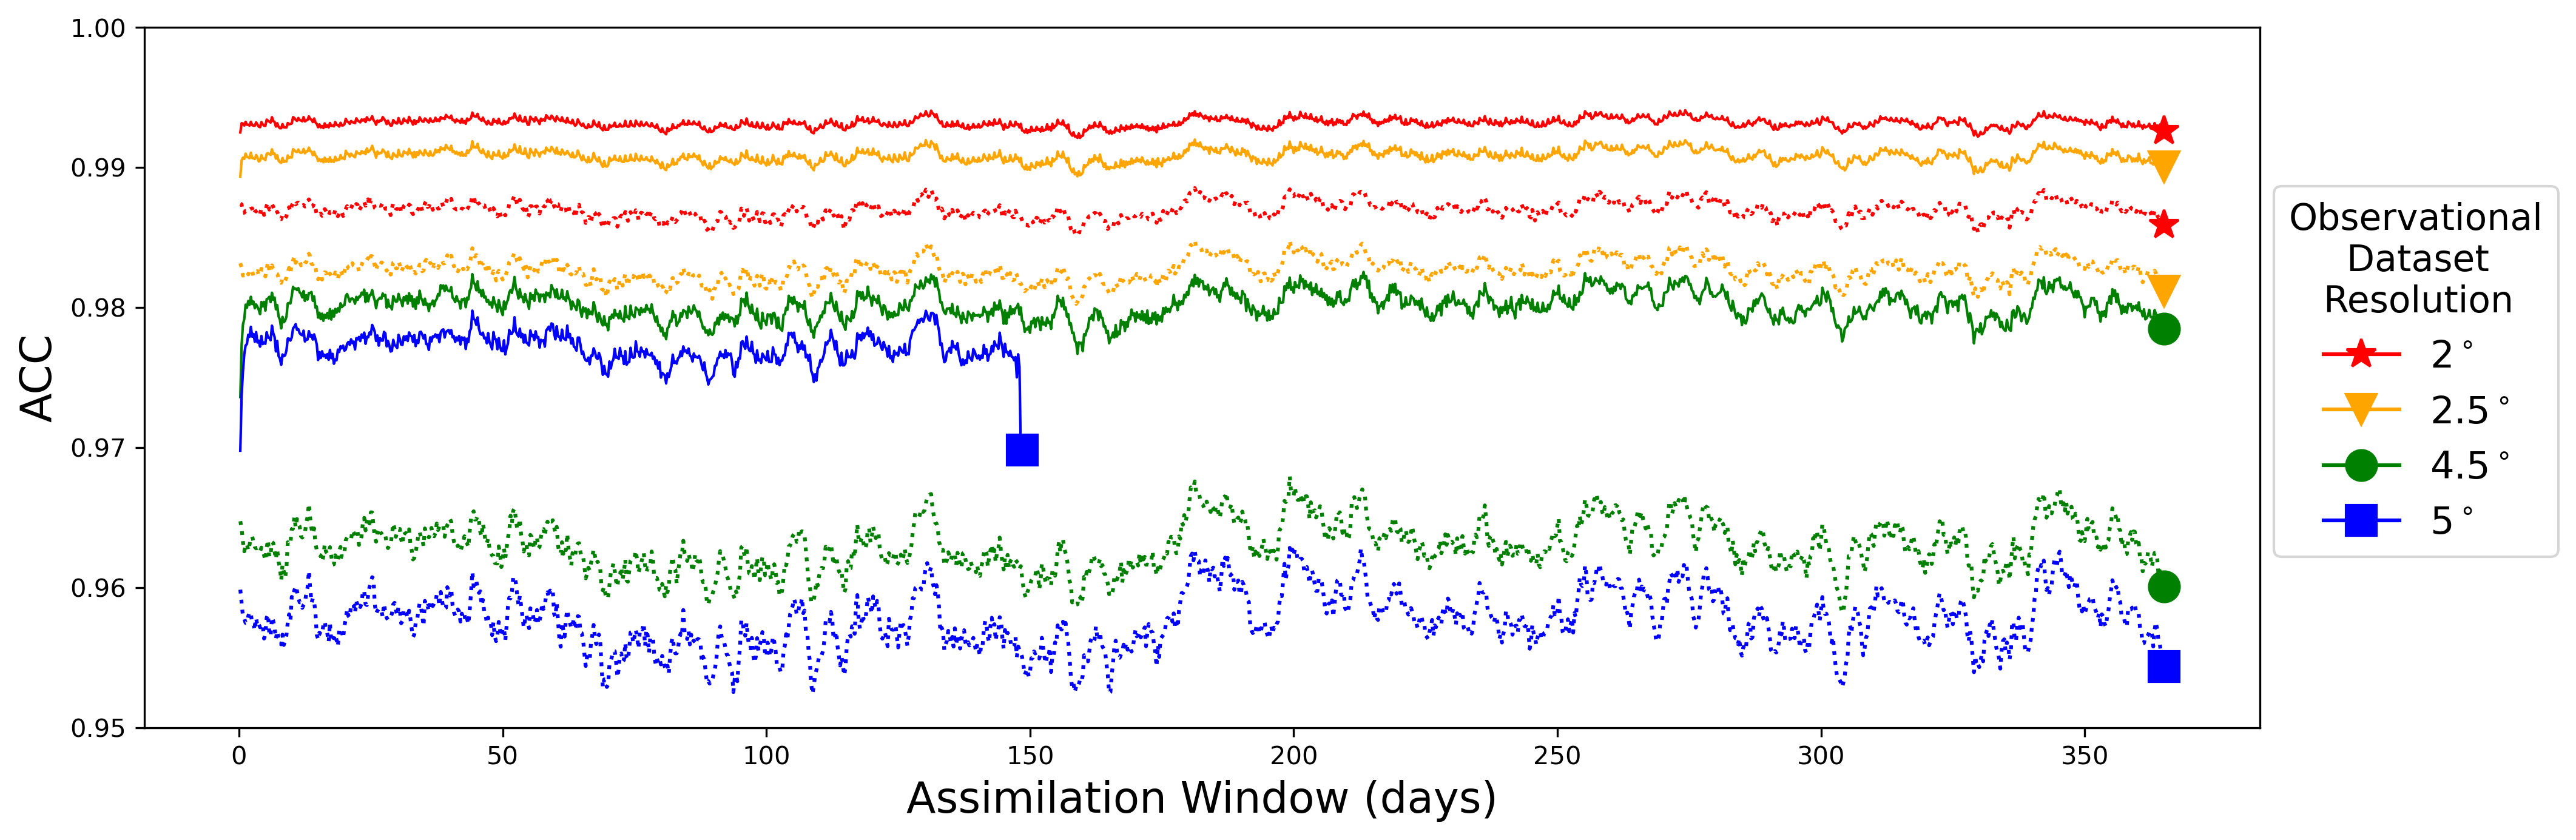

In [20]:
from matplotlib.pyplot import figure
figure(figsize=(15*1, 5*1), dpi=300)


rmse = []
rmse_se = []
acc = []
acc_se = []
path = "/pscratch/sd/m/maadrian/output/ERA5/2023/vary_obs"

acc_mean_list = []
acc_std_list = []
acc_tpt_list = []
shapes = ["*", "v", "o", "s"]
n=8
acc = np.load("/pscratch/sd/m/maadrian/output/ERA5/2023/vary_obs/new_framework_GLOBAL_FCNinterpyHnotIdyLdx_q0.5r0.0001n1woodbury_qfactor{}GLOBALsmooth4_041124/enkf_filtering_acc_factor{}.npy".format(n,n))
acc_se = np.load("/pscratch/sd/m/maadrian/output/ERA5/2023/vary_obs/new_framework_GLOBAL_FCNinterpyHnotIdyLdx_q0.5r0.0001n1woodbury_qfactor{}GLOBALsmooth4_041124/enkf_se_filtering_acc_factor{}.npy".format(n,n))
acc_mean_list.append(acc.mean())
acc_std_list.append(np.std(acc))
acc_tpt_list.append(len(acc))
t = len(acc)

plt.plot(np.arange(6/24,(len(acc)+1)*6/24,6/24), np.array(acc), c = 'r', linewidth = 1)
upscaled_obs =  np.load("/pscratch/sd/m/maadrian/output/ERA5/2023/vary_obs/new_framework_GLOBAL_FCNinterpyHnotIdyLdx_q0.5r0.0001n1woodbury_qfactor8GLOBALsmooth4_041124/acc_upscaled_obs.npy").mean(axis = (1,2))
plt.plot(np.arange(6/24,(len(upscaled_obs)+1)*6/24,6/24), upscaled_obs, c = 'r', linestyle = 'dotted')
plt.plot((len(upscaled_obs)+1)*6/24, upscaled_obs[-1], c = 'r', marker = shapes[0], markersize=12 )
plt.plot((t+1)*6/24, np.array(acc)[-1], c = 'r', label = "2$^\circ$", marker = shapes[0], markersize = 12)

obs_list = [10,18,20]
degrees = ["2.5$^\circ$", "4.5$^\circ$", "5$^\circ$"]

for n in range(len(obs_list)):
    acc = np.load(path + "/new_framework_GLOBAL_FCNinterpyHnotIdyLdx_q0.5r0.0001n1woodbury_qfactor{}GLOBALsmooth4_041124/enkf_filtering_acc_factor{}.npy".format(obs_list[n],obs_list[n]))
    acc_se = np.load(path + "/new_framework_GLOBAL_FCNinterpyHnotIdyLdx_q0.5r0.0001n1woodbury_qfactor{}GLOBALsmooth4_041124/enkf_filtering_acc_factor{}.npy".format(obs_list[n],obs_list[n]))
    acc_mean_list.append(acc.mean())
    acc_tpt_list.append(len(acc))
    acc_std_list.append(np.std(acc))
    plt.plot(np.arange(6/24,(len(acc)+1)*6/24,6/24), np.array(acc), c = c_list[n],linewidth = 1)

    plt.plot((len(acc)+1)*6/24, [np.array(acc)[-1]], marker = shapes[n+1], markersize = 12, c = c_list[n], label = "{}".format(degrees[n]))
    upscaled_obs =  np.load(path + "/new_framework_GLOBAL_FCNinterpyHnotIdyLdx_q0.5r0.0001n1woodbury_qfactor{}GLOBALsmooth4_041124/acc_upscaled_obs.npy".format(obs_list[n])).mean(axis = (1,2))
    plt.plot(np.arange(6/24,(t+1)*6/24,6/24), upscaled_obs, c = c_list[n], linestyle = 'dotted')
    plt.plot((t+1)*6/24, upscaled_obs[-1], c = c_list[n], marker = shapes[n+1], markersize=12 )
    
plt.legend(fontsize=15, loc = "upper right", title = "Observational\n     Dataset\n   Resolution", title_fontsize = "x-large", bbox_to_anchor=(1.15, 0.8))
plt.ylabel("ACC",fontsize=17)
plt.ylim((0.95,1))
plt.xlabel("Assimilation Window (days)",fontsize=17)
plt.savefig("../figures/obs_acc_over_time.png",bbox_inches = 'tight',dpi=300)
plt.show()


# Visualizing the filter divergence for 5$^\circ$ observations

In [58]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt


In [200]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import matplotlib.patches as patches
import h5py 


In [202]:
tpt = 17
feature = 0
gt = h5py.File("/pscratch/sd/m/maadrian/data/ERA5_2023/2023/2023.h5")['fields'][tpt+1,feature,:,:]
m = np.load("/pscratch/sd/m/maadrian/stats_v0/ERA5/global_means.npy")[0,feature,:,:]
s = np.load("/pscratch/sd/m/maadrian/stats_v0/ERA5/global_stds.npy")[0, feature, :,:]
#gt = (gt-m)/s
gt_maxU10 = np.max(gt)
gt_minU10 = np.min(gt)
data = np.load(f"/pscratch/sd/m/maadrian/output/ERA5/2023/vary_obs/REVISIONSnew_framework_GLOBAL_FCNinterpyHnotIdyLdx_q0.5r0.0001n1woodbury_qfactor18GLOBALsmooth4_041124/update{tpt}.npy")
data = (data+m)*s

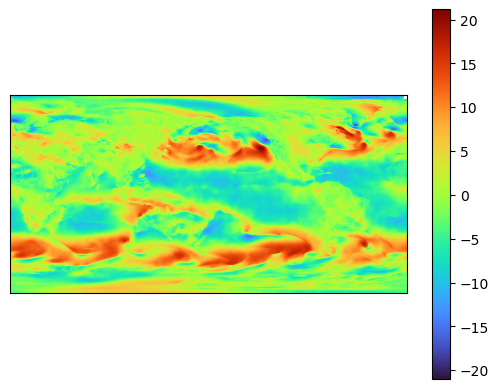

In [203]:
u10 = np.ma.masked_where( data[0,0,feature,:,:] < gt_minU10*1.1 , data[0,0,feature,:,:])
u10 = np.ma.masked_where(u10 > gt_maxU10*1.1, u10)
cmap = matplotlib.cm.turbo  
cmap.set_bad(color='white')
fig = plt.imshow(u10, cmap = cmap)

plt.xticks([])
plt.yticks([])

plt.colorbar()
plt.show()

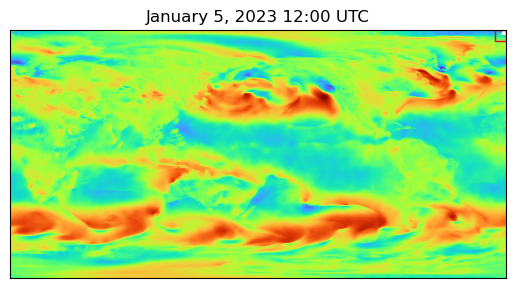

In [205]:

from mpl_toolkits.axes_grid1 import make_axes_locatable 
  
fig, ax = plt.subplots()   

im = plt.imshow(u10, cmap = cmap, vmin = np.min(u10), vmax = np.max(u10)) 
plt.title("January 5, 2023 12:00 UTC")
rect = patches.Rectangle((1440-32, 0), 32, 32, linewidth=1, edgecolor='r', facecolor='none')
ax.add_patch(rect)

plt.setp(ax, xticks=[], yticks=[])
plt.savefig("../figures/no_smoothing_div1.png", bbox_inches='tight',dpi=300)
plt.show() 

[]

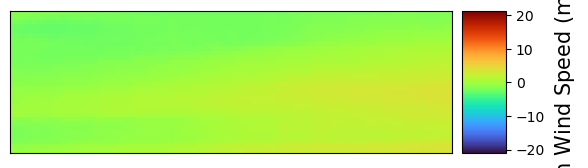

In [221]:
fig, ax = plt.subplots()   
#im = plt.imshow(u10[0:32,1440-32:], cmap = cmap, vmin = np.min(u10), vmax = np.max(u10)) 
s =100
im = plt.imshow(u10[720-32:,s:s+100], cmap = cmap, vmin = np.min(u10), vmax = np.max(u10)) 

divider = make_axes_locatable(ax)  
colorbar_axes = divider.append_axes("right", 
                                    size="10%", 
                                    pad=0.1) 
cbar = plt.colorbar(im, cax=colorbar_axes)

cbar.set_label('U10m Wind Speed (m  s$^{-1}$)',size = 15)
plt.setp(ax, xticks=[], yticks=[])
#plt.savefig("../figures/no_smoothing_div2.png", bbox_inches='tight',dpi=300)

# $5^\circ$ Observations Filter Divergence

In [98]:
tpt = 592
data = np.load(f"/pscratch/sd/m/maadrian/output/ERA5/2023/vary_obs/new_framework_GLOBAL_FCNinterpyHnotIdyLdx_q0.5r0.0001n1woodbury_qfactor20GLOBALsmooth4_041124/update{tpt}.npy")
gt = h5py.File("/pscratch/sd/m/maadrian/data/ERA5_2023/2023/2023.h5")['fields'][tpt+1,:2,:,:]
gt_ws = np.sqrt(gt[0,:,:]**2 + gt[1,:,:]**2)
gt_ws_max = np.max(gt_ws)
print(gt_ws_max)
m = np.load("/pscratch/sd/m/maadrian/stats_v0/ERA5/global_means.npy")
s = np.load("/pscratch/sd/m/maadrian/stats_v0/ERA5/global_stds.npy")
u10 = (data[0,0,0,:,:]+ m[0,0,0,0])*s[0,0,0,0]
v10 =(data[0,0,1,:,:]+ m[0,1,0,0])*s[0,1,0,0]
ws = np.sqrt(u10**2 + v10**2)

ws = np.ma.masked_where( ws>gt_ws_max+0.001, ws)
cmap = matplotlib.cm.turbo  
cmap.set_bad(color='white')

30.140345


/tmp/ipykernel_1334993/2925471305.py:21: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig('../figures/5degree_filter_divergence1.png', bbox_inches='tight',dpi=300)


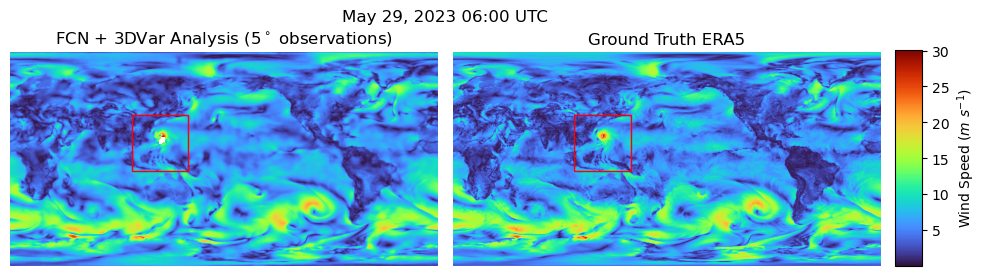

In [99]:
fig, ax = plt.subplots(1,2, figsize=(9, 9), tight_layout=True)
fig.suptitle("May 29, 2023 06:00 UTC",y=0.65)

#plt.figure(figsize=(20,12))
ax0 = ax[0].imshow(ws, vmin = 0, vmax = gt_ws_max, cmap = cmap)
ax1 = ax[1].imshow(gt_ws,cmap=cmap, vmax = gt_ws_max)
rect1 = patches.Rectangle((410, 210), 190, 190, linewidth=1, edgecolor='r', facecolor='none')
rect2 = patches.Rectangle((410, 210), 190, 190, linewidth=1, edgecolor='r', facecolor='none')
ax[0].add_patch(rect1)
ax[1].add_patch(rect2)
ax[0].axis("off")
ax[1].axis("off")
ax[0].set_title("FCN + 3DVar Analysis $(5^\circ$ observations)")
ax[1].set_title("Ground Truth ERA5")

fig.subplots_adjust(right=0.15)
cbar_ax = fig.add_axes([1, 0.365, 0.03, 0.24])

cbar = fig.colorbar(ax1, cax=cbar_ax)
cbar.set_label('Wind Speed $(m \ s^{-1})$') 
plt.savefig('../figures/5degree_filter_divergence1.png', bbox_inches='tight',dpi=300)
plt.show()


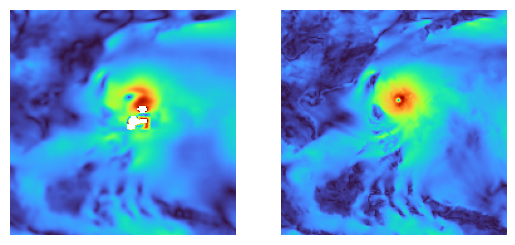

In [164]:
fig, ax = plt.subplots(1,2)
ax[0].imshow(ws[210:390, 410:590], cmap = 'turbo')
ax[1].imshow(gt_ws[210:390, 410:590], cmap = 'turbo')
ax[0].axis("off")
ax[1].axis("off")
plt.savefig('../figures/5degree_filter_divergence2.png', bbox_inches='tight',dpi=300)
plt.show()

# 4.5$^\circ$ Observation 3DVar Forecasting Divergence

In [1]:
import numpy as np
init849 = np.load("/pscratch/sd/m/maadrian/output/ERA5/2023/vary_obs/new_framework_GLOBAL_FCNinterpyHnotIdyLdx_q0.5r0.0001n1woodbury_qfactor18GLOBALsmooth4_020425_minus4/update849.npy")[0,0,:2,:,:]#041124/update849.npy")[0,0,:2,:,:]
init850 = np.load("/pscratch/sd/m/maadrian/output/ERA5/2023/vary_obs/new_framework_GLOBAL_FCNinterpyHnotIdyLdx_q0.5r0.0001n1woodbury_qfactor18GLOBALsmooth4_020425_minus4/update850.npy")[0,0,:2,:,:]#041124/update850.npy")[0,0,:2,:,:]
m = np.load("/pscratch/sd/m/maadrian/stats_v0/ERA5/global_means.npy")[0,:2,:,:]
s = np.load("/pscratch/sd/m/maadrian/stats_v0/ERA5/global_stds.npy")[0, :2, :,:]

init849 = (init849+m)*s

init849_ws = np.sqrt(init849[0,:,:]**2 + init849[1,:,:]**2)
import h5py
data = h5py.File("/pscratch/sd/m/maadrian/output/ERA5/2023/failure_preds_020425_minus4.h5")['fields'][0,2::4,:2,:,:]#[:,3::4,0,:,:]

data = (data+m)*s

forecast_ws = np.sqrt(data[:,0,:,:]**2 + data[:,1,:,:]**2)

print(init849_ws.shape, forecast_ws.shape)
data = np.concatenate((np.expand_dims(init849_ws,0),forecast_ws), axis = 0)[:3,:,:]

(720, 1440) (5, 720, 1440)


In [57]:
import h5py

era5 = h5py.File("/pscratch/sd/m/maadrian/data/ERA5_2023/2023/2023.h5")['fields'][849+1,:2,:,:]

In [55]:
era5_ws = np.sqrt(era5[0,:,:]**2 + era5[1,:,:]**2)

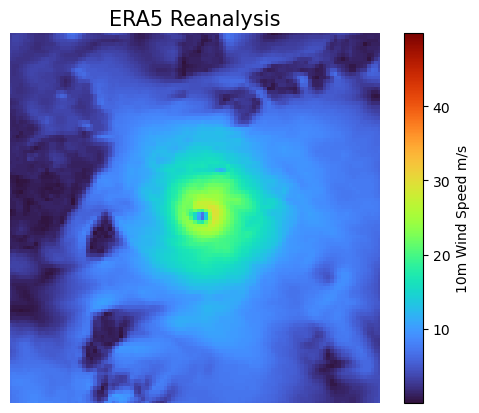

In [61]:
plt.imshow(era5_ws, cmap = 'turbo',  vmin = np.min(data[0,:,:]), vmax = np.max(data[0,:,:]))
plt.xlim(460,560)
plt.ylim(310,210)
plt.axis('off')
plt.title("ERA5 Reanalysis",size = 15)
plt.colorbar(label = "10m Wind Speed m/s")
plt.savefig("../figures/era5_849.png", bbox_inches = "tight", dpi=300)

/tmp/ipykernel_1334993/1427482458.py:32: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig('../figures/forecast_divergence1.png', bbox_inches='tight',dpi=300)


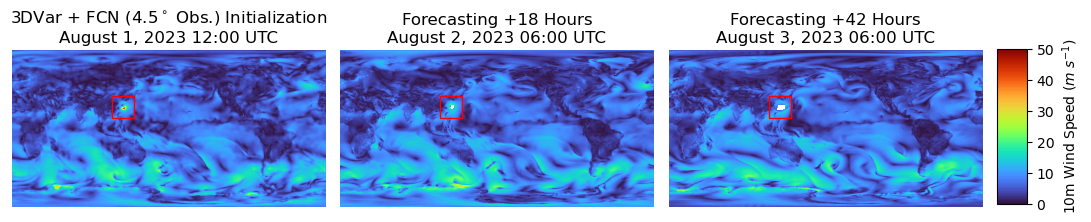

In [198]:
fig, axes = plt.subplots(1,3, figsize=(10, 5), tight_layout=True)
count = 0
vmin = np.min(init849_ws); vmax = np.max(init849_ws)

hours = [0, 18,42]
for ax in axes:
    
    ws = np.ma.masked_where( data[count, :,:]> vmax , data[count, :,:])
    cmap = matplotlib.cm.turbo  # Can be any colormap that you want after the cm
    cmap.set_bad(color='white')
    im = ax.imshow(ws, vmin = 0, vmax = 50, cmap = cmap)
    rect = patches.Rectangle((460, 210), 100, 100, linewidth=1, edgecolor='r', facecolor='none')
    ax.add_patch(rect)
    if count == 0:
        ax.set_title("3DVar + FCN (4.5$^\circ$ Obs.) Initialization\nAugust 1, 2023 12:00 UTC")
    elif count == 1:
        ax.set_title("Forecasting +18 Hours\nAugust 2, 2023 06:00 UTC")
    else:
        ax.set_title("Forecasting +42 Hours\nAugust 3, 2023 06:00 UTC")
    ax.axis("off")
    count += 1


fig.subplots_adjust(right=0.35)
cbar_ax = fig.add_axes([1, 0.35, 0.03, 0.31])

cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label('10m Wind Speed $(m \ s^{-1})$') 
plt.savefig('../figures/forecast_divergence1.png', bbox_inches='tight',dpi=300)
plt.show()

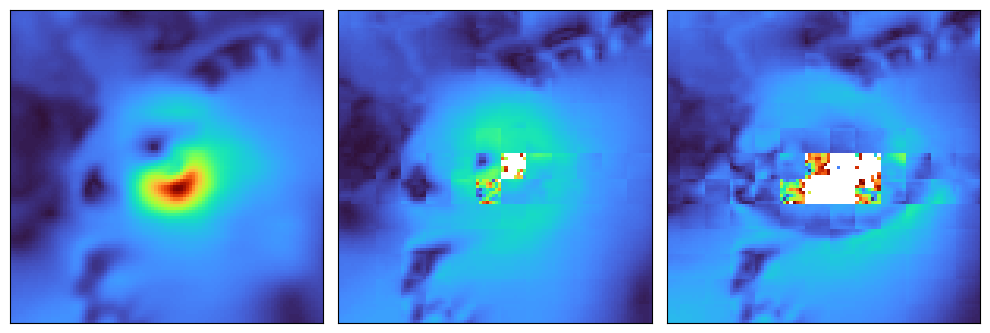

In [199]:
fig, axes = plt.subplots(1,3, figsize=(10, 5), tight_layout=True)
count = 0
vmin = np.min(init849_ws); vmax = np.max(init849_ws)
for ax in axes:
    
    ws = np.ma.masked_where( data[count, :,:]> vmax , data[count, :,:])

    cmap = matplotlib.cm.turbo 
    cmap.set_bad(color='white')
    im = ax.imshow(ws[210:210+100, 460:460+100], vmin = 0, vmax = 50, cmap = cmap)
    count += 1


fig.subplots_adjust(right=0.35)
plt.setp(axes, xticks=[], yticks=[])
plt.savefig('../figures/forecast_divergence2.png', bbox_inches='tight',dpi=300)
plt.show()